#  Phishing Email Generation

Ce notebook a un double objectif :

1. **Entraîner un classifieur d’emails de phishing** à l’aide de techniques classiques de NLP (nettoyage, vectorisation, Naive Bayes).
2. **Utiliser le prompt engineering** sur un modèle de langage avancé (type GPT) pour générer des emails de phishing suffisamment convaincants pour **tromper ce classifieur**.

Ce projet s’inscrit dans une logique de **red teaming / adversarial NLP**.


# Construction d'un classifieur Naive Bayes

## Librairies

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
#import kagglehub
import glob
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from datasets import load_dataset
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
import names
from datetime import datetime, timedelta
from faker import Faker
import random
import openai
from openai import timeout
import json
from mistralai import Mistral
tqdm.pandas()

##  Chargement du Dataset

Le fichier `merged_data.csv` contient des emails labellisés :
- `0` : email légitime
- `1` : email de phishing

Nous allons inspecter la structure des données avant de les préparer pour le modèle.

Origine du dataset: https://zenodo.org/records/8339691

In [8]:




csv_files = glob.glob(os.path.join("data", "*.csv"))
csv_files.remove('data/adult_data.csv')
csv_files.remove('data/merged_data.csv')
df = []
for f in csv_files:
    df_temp = pd.read_csv(f)
    df_temp['origin_dataset'] = os.path.basename(f)
    df.append(df_temp)


df = pd.concat(df, ignore_index=True)




df.head()

,sender,receiver,date,subject,body,urls,label,origin_dataset,text_combined
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,0.0,1,Nigerian_Fraud.csv,NaN
1,Mr. Ben Suleman <bensul2004nng@spinfinder.com>,R@M,"Thu, 31 Oct 2002 05:10:00 -0000",URGENT ASSISTANCE /RELATIONSHIP (P),"Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",0.0,1,Nigerian_Fraud.csv,NaN
2,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:17:55 +0100",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0.0,1,Nigerian_Fraud.csv,NaN
3,PRINCE OBONG ELEME <obong_715@epatra.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 22:44:20 -0000",GOOD DAY TO YOU,FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,0.0,1,Nigerian_Fraud.csv,NaN
4,Maryam Abacha <m_abacha03@www.com>,R@M,"Fri, 01 Nov 2002 01:45:04 +0100",I Need Your Assistance.,"Dear sir, \n \nIt is with a heart full of hope...",0.0,1,Nigerian_Fraud.csv,NaN


In [9]:
df['body'] = df['body'].fillna('') + ' ' + df['text_combined'].fillna('')
df.drop(columns=['sender', 'receiver', 'subject', 'urls', 'text_combined'], inplace=True)
df.head()

,date,body,label,origin_dataset
0,"Thu, 31 Oct 2002 02:38:20 +0000",FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-2...,1,Nigerian_Fraud.csv
1,"Thu, 31 Oct 2002 05:10:00 -0000","Dear Friend,\n\nI am Mr. Ben Suleman a custom ...",1,Nigerian_Fraud.csv
2,"Thu, 31 Oct 2002 22:17:55 +0100",FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,1,Nigerian_Fraud.csv
3,"Thu, 31 Oct 2002 22:44:20 -0000",FROM HIS ROYAL MAJESTY (HRM) CROWN RULER OF EL...,1,Nigerian_Fraud.csv
4,"Fri, 01 Nov 2002 01:45:04 +0100","Dear sir, \n \nIt is with a heart full of hope...",1,Nigerian_Fraud.csv


In [ ]:
df.to_csv('data/merged_data.csv', index=False)

In [10]:
original_df=df.copy()

##  Répartition des emails vrais vs phishing

Il est crucial de vérifier l’équilibre entre les classes afin d’éviter un biais lors de l’entraînement.


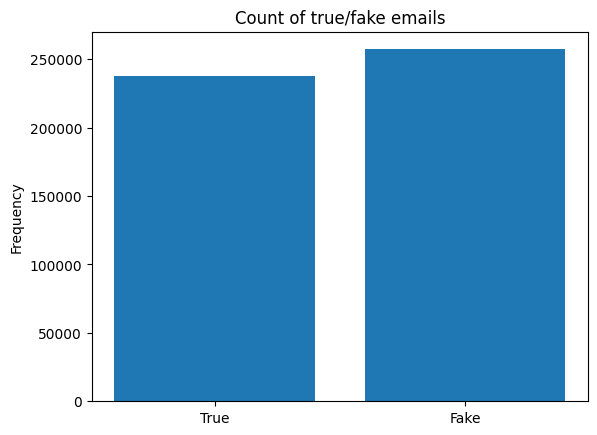

In [38]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

On voit que le dataset est équilibré on aura donc pas de manipulations d'under/over sampling

## Data preprocessing : Nettoyage et Prétraitement

Cette étape standardise les emails :
- suppression des balises HTML, des URLs, de la ponctuation
- mise en minuscules
- lemmatisation et suppression des stopwords

Cela prépare les textes pour leur vectorisation.

Cleaning

In [11]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\['
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_7906/884032786.py:10: SyntaxWarning: invalid escape sequence '\['
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_7906/884032786.py:10: SyntaxWarning: invalid escape sequence '\S'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_7906/884032786.py:10: SyntaxWarning: invalid escape sequence '\w'
  sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.pun

In [12]:
df['body']=df['body'].progress_apply(clean_text)

100%|██████████| 164972/164972 [00:33<00:00, 4899.74it/s]


In [13]:

df.sample(n=10)['body']

61527      seismic data via satellite preparing summary ...
7825       contenttype textplain charsetusascii formatfl...
142830    vince fyibelow is the comparison of the comput...
47153     yeah me too often go in there for the lovely f...
144275    given the growth in ees it has become apparent...
17964     metabolic warm trap retrovision vicinal naturo...
60805      todd kimberlain vince vasant know todd kimber...
99584      pricecomparisonshopping pricecomparisonshoppi...
143617    vince and stinson i did some reserach on the o...
18274     us licensed health shop  shipping no rx requir...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [14]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    '''Remove stop words and lemmatize the text.'''
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 164972/164972 [01:01<00:00, 2702.71it/s]


In [15]:
df.sample(n=10)["body"]

103244     martin v löwis qpnyslvloewisde since  python ...
151529    maybe   letcha know       original message    ...
23954           youre sick tired small  inch click chan...
38319     helloplease find final update number staff att...
73094      window operating system  brawl fentonapproxim...
87510      bitpipe sabitpipecom bitpipecom knowledgealer...
59897      free latex go http www winedt com select down...
44041     new comment post  word  picturesauthor  admin ...
141332    vincent kaminski received fax labor day weeken...
110699     abe spence abeutetit grows longer beg penetra...
Name: body, dtype: object

In [16]:
def preprocessing(text):
    '''Helper to prepare text for model input by combining cleaning, stopword removal, and lemmatization.'''
    return stop_lem(clean_text(text))

In [17]:

preprocessing('This is a test email. Please ignore it. https://example.com [test] 1234') 

'test email please ignore   '

To make data manipulation easier

In [18]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

# Statistiques Descriptives

##  Nuage de mots : Emails légitimes

Ce nuage de mots met en évidence les mots les plus fréquents dans les emails considérés comme légitimes.  
Cela donne une intuition visuelle des termes typiquement utilisés dans ce type de messages.


(-0.5, 399.5, 199.5, -0.5)

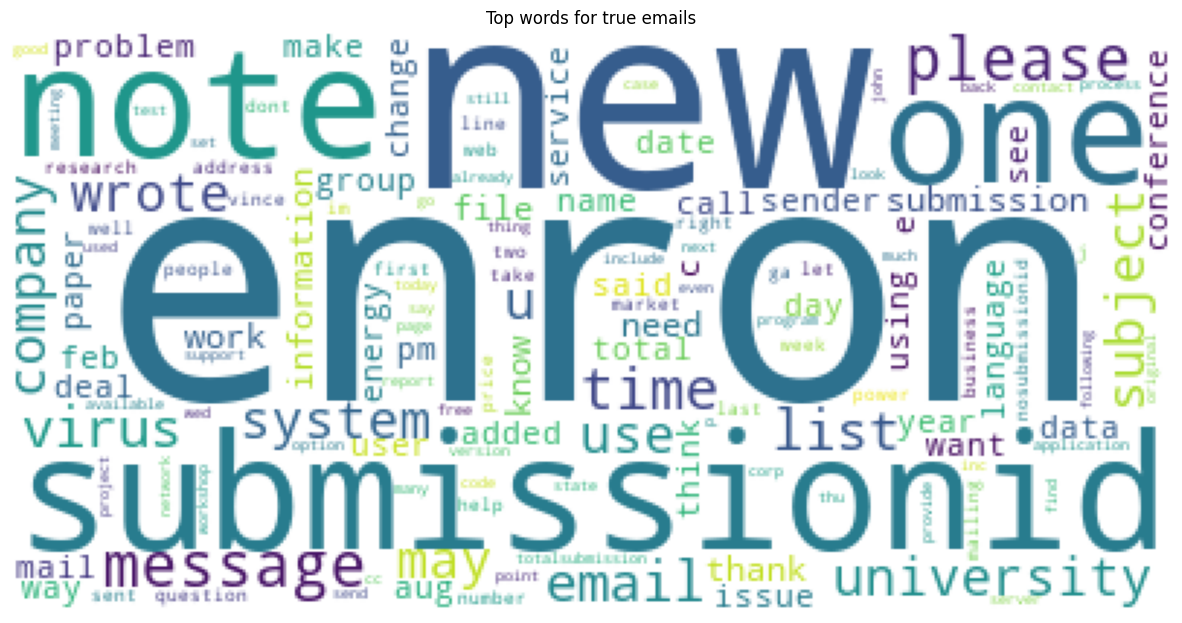

In [47]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in true_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for true emails')
plt.imshow(wc)
plt.axis("off")

##  Nuage de mots : Emails de phishing

Voici les mots les plus courants retrouvés dans les emails malveillants.  
On peut les comparer au nuage précédent pour repérer les différences de vocabulaire.


(-0.5, 399.5, 199.5, -0.5)

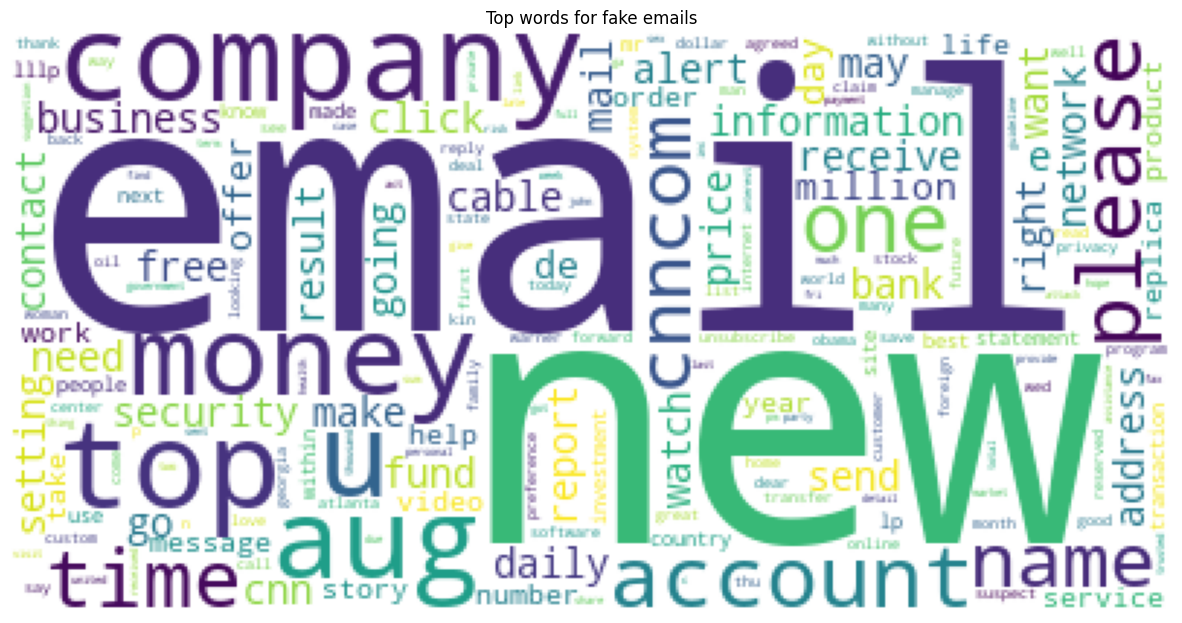

In [48]:
wc=WordCloud(
    background_color='white', 
    max_words=200, 
    collocations=False
)

wc.generate(' '.join(text for text in fake_df['body']))
plt.figure(figsize=(15,10))
plt.title('Top words for fake emails')
plt.imshow(wc)
plt.axis("off")

##  Distribution de la longueur des emails

On compare ici les longueurs des emails légitimes et frauduleux.  
Cela peut mettre en lumière des différences stylistiques entre les deux types d’emails.


100%|██████████| 257346/257346 [00:00<00:00, 990989.14it/s]


Text(0.5, 1.0, 'KDE plot')

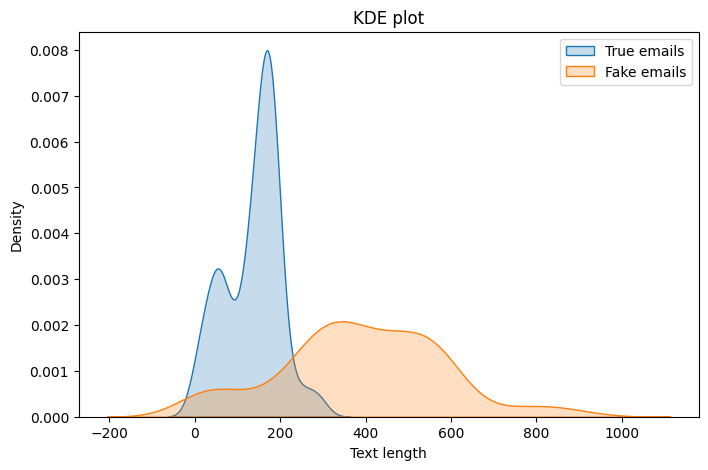

In [49]:
plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='True emails')  
sns.kdeplot(fake_df['body'].progress_apply(len).value_counts().sort_index()[:150], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Text length")
plt.ylabel("Density")
plt.title("KDE plot")

In [50]:
def count_dict(data):
    words=''.join(text for text in data['body']).split(' ')
    word_counts={}
    for word in tqdm((words)):
        word_counts[word]=word_counts.get(word,0) + 1
    word_counts.pop('')
    s=sum(word_counts.values())
    return {k:v/s for k,v in word_counts.items()}
true_word_count=count_dict(true_df)
fake_word_count=count_dict(fake_df)

100%|██████████| 35493512/35493512 [00:06<00:00, 5620623.38it/s]


##  Loi de Zipf : Fréquence des mots

La loi de Zipf est une régularité empirique observée dans les langues naturelles :  
la fréquence d’un mot est **inversement proportionnelle à son rang** dans la liste des mots triés par fréquence.

Elle s’écrit mathématiquement :

$
f(r) \propto \frac{1}{r}
$

où :

- $f(r)$ est la fréquence du mot de rang $r$,
- $r$ est le rang du mot (1 pour le mot le plus fréquent, 2 pour le second, etc.).

Ce graphique compare la distribution réelle des mots dans notre dataset à une distribution idéale de Zipf.  
Un écart significatif peut révéler une structure artificielle ou anormale du texte (comme c’est souvent le cas dans les emails de phishing).


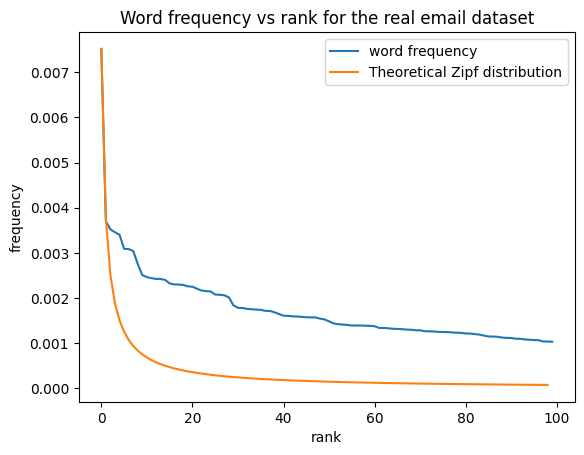

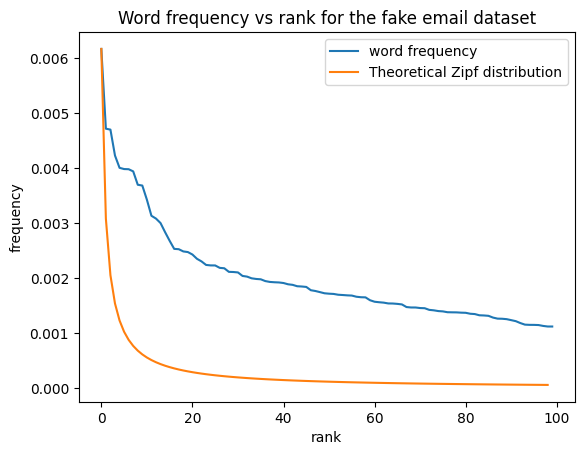

In [51]:
plt.plot(list(sorted(true_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(true_word_count.values()))/(x) for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the real email dataset')
plt.legend()
plt.show()
plt.plot(list(sorted(fake_word_count.values(),reverse=True))[:100],label='word frequency')
plt.plot([max(list(fake_word_count.values()))/x for x in np.arange(100)[1:]],label='Theoretical Zipf distribution')
plt.ylabel('frequency')
plt.xlabel('rank')
plt.title('Word frequency vs rank for the fake email dataset')
plt.legend()

##  Analyse de Sentiment (Polarity & Subjectivity)

L’analyse de sentiment permet de mesurer :
- **Polarity** : si l’email est globalement positif ou négatif
- **Subjectivity** : si l’email contient des opinions ou des faits

On cherche à voir si les emails de phishing sont plus "persuasifs", donc plus subjectifs.


In [52]:
def gen_sentiment(df,col):
    def pol(x):
        try:
            return TextBlob(x).sentiment.polarity
        except:
            return x
    def sub(x):
        try:
            return TextBlob(x).sentiment.subjectivity
        except:
            return x


    df["polarity"]=df[col].progress_apply(pol)
    df["subjectivity"]=df[col].progress_apply(sub)
    
    
gen_sentiment(true_df,'body')
gen_sentiment(fake_df,'body')

100%|██████████| 237570/237570 [01:26<00:00, 2735.86it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_67859/4165469104.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["polarity"]=df[col].progress_apply(pol)
100%|██████████| 237570/237570 [01:26<00:00, 2757.31it/s]
/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_67859/4165469104.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["subjectivity"]=df[col].progress_apply(sub)
100%|██████████| 257346/257346 [00:56<00:00, 456

Text(0.5, 1.0, 'Density estimation of subjectivity')

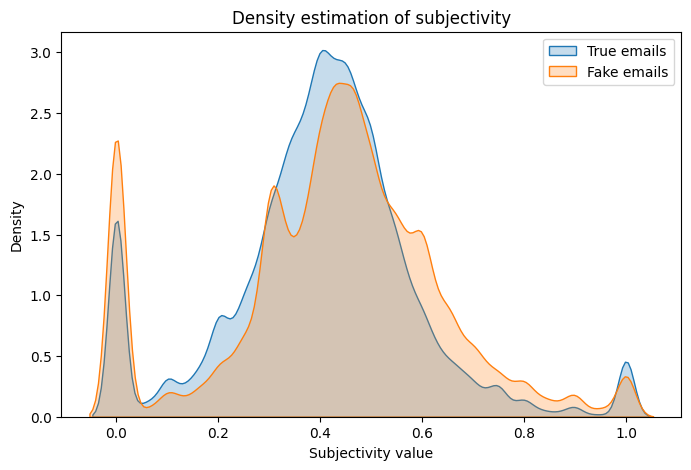

In [54]:
plt.figure(figsize=(8, 5))
sns.kdeplot(true_df['subjectivity'],fill=True,label='True emails')  
sns.kdeplot(fake_df['subjectivity'], fill=True,label='Fake emails')  
plt.legend()
plt.xlabel("Subjectivity value")
plt.ylabel("Density")
plt.title("Density estimation of subjectivity")

##  Nombre moyen de liens par email

Cette statistique compare la quantité de liens contenus dans les emails légitimes vs frauduleux.  
Les emails de phishing contiennent souvent plus de liens malveillants.


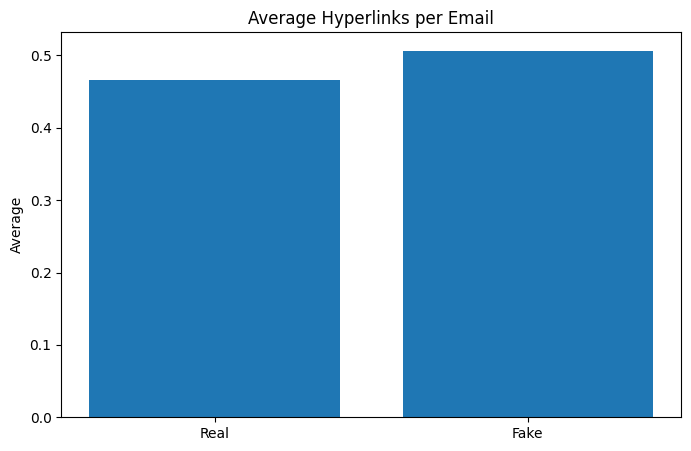

In [ ]:
def count_hyperlinks(text):
        return len(re.findall(r'http+', text))


def count_attachments(text):
        return len(re.findall(r'attachment|file|pdf|image|zip|doc', text, re.IGNORECASE))


df["hyperlink_count"] = original_df["body"].apply(count_hyperlinks)


fig, ax = plt.subplots(1, 1, figsize=(8, 5))


ax.bar(["Real", "Fake"], df.groupby("label")["hyperlink_count"].mean())
ax.set_title("Average Hyperlinks per Email")
ax.set_ylabel("Average")

plt.show()

##  Distribution temporelle des emails

Ces graphiques explorent la répartition des emails en fonction :
- du **mois**
- du **jour du mois**
- du **jour de la semaine**

Ils permettent d'observer s’il existe des pics ou des stratégies temporelles dans l’envoi des emails de phishing.


In [59]:
dataset = load_dataset("SetFit/enron_spam")


dates_labels = list(zip(dataset['train']['date'], dataset['train']['label']))
print(dates_labels[:10]) 

Repo card metadata block was not found. Setting CardData to empty.


[(datetime.datetime(2005, 6, 18, 0, 0), 1), (datetime.datetime(2001, 6, 19, 0, 0), 0), (datetime.datetime(2004, 9, 11, 0, 0), 1), (datetime.datetime(2000, 12, 12, 0, 0), 0), (datetime.datetime(2005, 2, 13, 0, 0), 1), (datetime.datetime(2005, 1, 18, 0, 0), 1), (datetime.datetime(2005, 2, 24, 0, 0), 1), (datetime.datetime(2002, 4, 21, 0, 0), 1), (datetime.datetime(2000, 2, 7, 0, 0), 0), (datetime.datetime(2005, 7, 22, 0, 0), 1)]


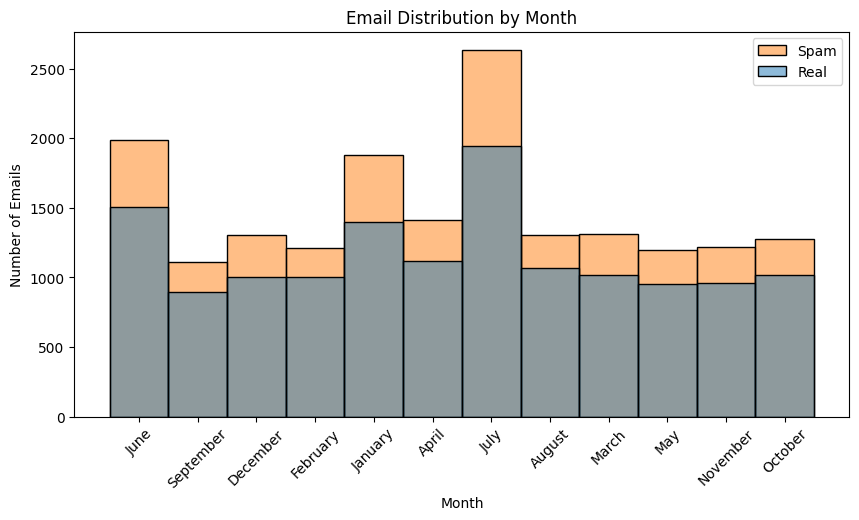

In [60]:
df_date = pd.DataFrame(dates_labels, columns=["date", "label"])
df_date["date"] = pd.to_datetime(df_date["date"], errors="coerce")
df_date["month"] = df_date["date"].dt.month_name()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="month", bins=12, hue=df["label"],discrete=True)


plt.xlabel("Month")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by Month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

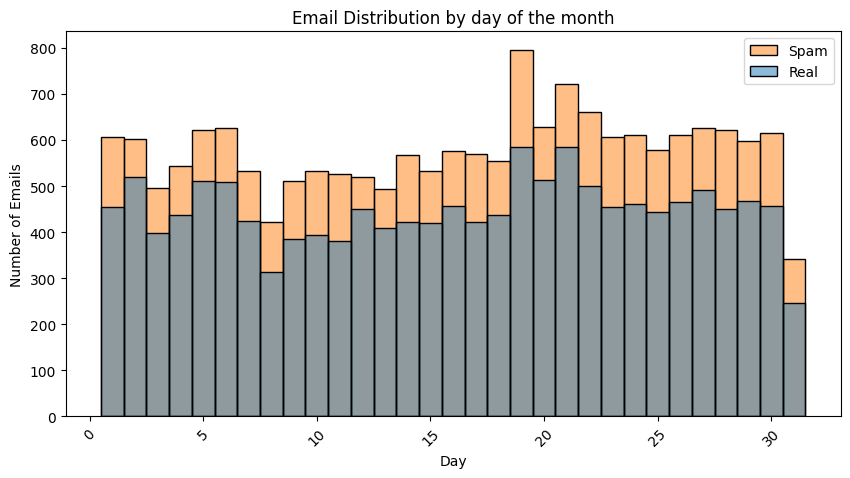

In [61]:
df_date["month_day"] = df_date["date"].apply(lambda x:x.day)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="month_day", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day")
plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the month")
plt.legend(labels=["Spam","Real"])
plt.xticks(rotation=45) 

plt.show()

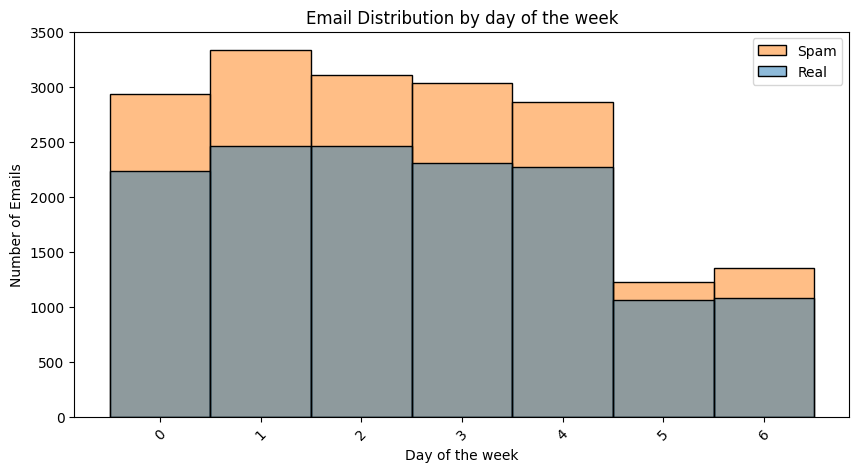

In [62]:
df_date["weekday"] = df_date["date"].apply(lambda x:x.weekday())

plt.figure(figsize=(10, 5))
sns.histplot(data=df_date, x="weekday", bins=31, hue=df["label"],discrete=True)


plt.xlabel("Day of the week")

plt.ylabel("Number of Emails")
plt.title("Email Distribution by day of the week")
plt.xticks(rotation=45) 
plt.legend(labels=["Spam","Real"])

plt.show()

# Naive Bayes Model

https://scikit-learn.org/stable/modules/naive_bayes.html

##  Split &  Vectorisation

Le jeu est divisé en `train` / `test`, puis transformé en vecteurs à l’aide de `CountVectorizer`, basé sur le bag-of-words.


In [51]:
from sklearn.model_selection import train_test_split

x_train_text, x_test_text, y_train, y_test = train_test_split(df["body"], df["label"], random_state=42)

# Keep a copy of the selected rows in original_df for text version
original_train_text = original_df.loc[x_train_text.index, "body"]
original_test_text = original_df.loc[x_test_text.index, "body"]

In [42]:
x_train_text.sample(n=10), y_train.sample(n=10)

(81296      hi sweetness hey babie course julie web perso...
 27074      daily top  cnncom top video story aug      pm...
 42222      additional comment mqlwfkfoapacheorg    would...
 35311     aff ev ord le able p n ha dqj rm ph yww cy med...
 23027     apology multiple postingssecond call paper wor...
 136272                             attached recent number  
 23805     premo herbal optionsyoure better solving softw...
 162453    good evening final decision made state mind go...
 72783      instant download  popular software scared fat...
 125940     theo van dinter felicityklugenet  contenttype...
 Name: body, dtype: object,
 72663     1
 73001     1
 117450    1
 102951    1
 145102    1
 46828     0
 2933      1
 113728    0
 19429     0
 131946    1
 Name: label, dtype: int64)

In [ ]:
vect=CountVectorizer()
vect.fit(x_train_text)


x_train=vect.transform(x_train_text)
x_test=vect.transform(x_test_text)

In [22]:
pickle.dump(vect,open("models/vectorizer.pkl","wb"))

##  Entraînement du Classifieur (Naive Bayes)

Un modèle `MultinomialNB` est entraîné sur les vecteurs de mots.
Il constitue notre **filtre anti-phishing de référence**.


In [23]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

##  Évaluation du Classifieur

On évalue la précision du modèle avec la `confusion matrix` et le score d’accuracy.


0.976432364279999

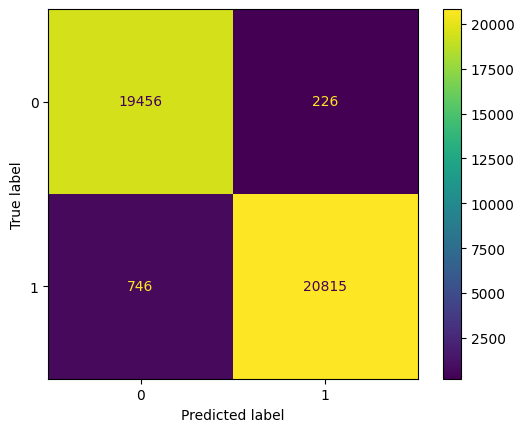

In [24]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

### Interprétabilité des Probabilités Logarithmiques dans Naive Bayes

Dans le contexte du classifieur Naive Bayes, les **probabilités logarithmiques** jouent un rôle clé pour comprendre et interpréter les décisions du modèle. Voici comment elles contribuent à l'interprétabilité :

#### 1. **Importance des Features**
- Les probabilités logarithmiques des caractéristiques $\log P(X_i|C)$ permettent d'identifier les mots ou expressions les plus influents pour chaque classe (phishing ou légitime).
- Par exemple, un mot avec une probabilité logarithmique élevée pour la classe "phishing" est fortement associé à cette catégorie.

#### 2. **Contribution des Mots**
- Lors de la prédiction, chaque mot présent dans un email contribue à la somme des probabilités logarithmiques pour chaque classe.
- Cela permet de décomposer la décision du modèle en contributions individuelles des mots, facilitant l'analyse des raisons derrière une prédiction.




## Visualisation de l'Importance des Features

La **Visualisation de l'Importance des Features** met en évidence les mots ou expressions les plus influents utilisés par le **classifieur Naive Bayes** pour distinguer entre les **emails légitimes** et les **emails de phishing**. Ces features sont classées en fonction de leurs scores d'importance, dérivés des log-probabilités du modèle.


In [ ]:

import plotly.express as px

def plot_top_features_interactive(vectorizer, model, n=20):
    """
    Create an interactive bar plot with color gradients for the top `n` features for each class.

    Parameters:
    - vectorizer: The CountVectorizer used to transform the data.
    - model: The trained MultinomialNB model.
    - n: The number of top features to display for each class.
    """
    feature_names = vectorizer.get_feature_names_out()
    class_labels = model.classes_

    for i, label in enumerate(class_labels):
        # Get the top `n` features for the current class
        sorted_indices = np.argsort(model.feature_log_prob_[i])[::-1][:n]
        top_features = feature_names[sorted_indices]
        top_log_probs = model.feature_log_prob_[i][sorted_indices]

        # Create a DataFrame for the features and their log probabilities
        df = pd.DataFrame({
            'Feature': top_features,
            'Log Probability': top_log_probs
        })

        # Create an interactive bar plot
        fig = px.bar(
            df,
            x='Log Probability',
            y='Feature',
            orientation='h',
            color='Log Probability',
            color_continuous_scale='Viridis',
            title=f"Top Features for {'phishing' if label == 1 else 'legitimate'} emails",
        )
        fig.update_layout(yaxis=dict(autorange="reversed"))
        fig.show()

plot_top_features_interactive(vect, nb)

## Interprétation du Graphique des Caractéristiques Principales

Le **Graphique des Caractéristiques Principales** fournit une représentation visuelle des mots (caractéristiques) les plus influents utilisés par le **classifieur Naive Bayes** pour distinguer entre les **emails de phishing** et les **emails légitimes**. Ces caractéristiques sont classées en fonction de leurs **log-probabilités**, qui indiquent la force de leur association avec chaque classe.

### Observations Clés :
1. **Emails de Phishing :**
   - Les mots avec des log-probabilités négatives élevées sont fortement associés aux emails de phishing.
   - Des termes courants liés au phishing tels que `money`, `bank`, `buisness` apparaissent en tête de cette catégorie.
   - Ces mots reflètent souvent le ton manipulateur et urgent des emails de phishing, visant à tromper les destinataires pour qu'ils agissent rapidement.

2. **Emails Légitimes :**
   - Les mots avec des log-probabilités négatives élevées sont davantage indicatifs des emails légitimes.
   - Des termes comme `time`, `submission`, `please` dominent cette catégorie.
   - Ces mots sont caractéristiques des communications professionnelles ou de routine, typiques des emails légitimes.




## Observation de la Contribution des Mots aux Prédictions

Pour mieux comprendre le processus de prise de décision du modèle, nous analysons la contribution des mots individuels aux prédictions pour des emails donnés. Cela implique d'examiner les poids attribués aux mots par le classifieur Naive Bayes et leur impact sur le résultat de la classification.

### Approche :

- Pour un email donné, nous extrayons les mots et leurs poids correspondants depuis le modèle.
- La contribution de chaque mot à la prédiction est visualisée, mettant en évidence les termes les plus influents.


/var/folders/yk/3f16fbd17g7cmxqc9gfqwh9h0000gp/T/ipykernel_7906/2858109491.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




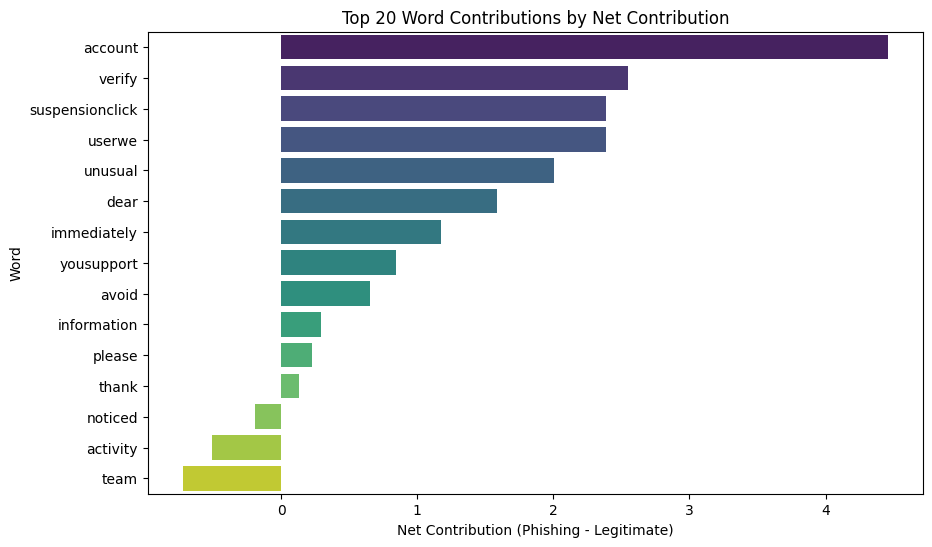

In [129]:
def word_contribution_analysis(email_text, vectorizer, model):
    """
    Analyze the contribution of each word in an email to the Naive Bayes classifier's prediction.

    Parameters:
    - email_text: str, the email text to analyze.
    - vectorizer: CountVectorizer, the vectorizer used to transform the data.
    - model: MultinomialNB, the trained Naive Bayes model.

    Returns:
    - contributions: DataFrame, showing each word and its contribution to the prediction.
    """
    # Preprocess the email text
    processed_text = preprocessing(email_text)
    
    # Transform the email text into a vector
    email_vector = vectorizer.transform([processed_text])
    
    # Get the feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Get the log probabilities for each class
    log_probs = model.feature_log_prob_
    
    # Extract the non-zero indices and their corresponding values
    non_zero_indices = email_vector.nonzero()[1]
    non_zero_values = email_vector.data
    
    # Calculate contributions for each word
    contributions = []
    for idx, count in zip(non_zero_indices, non_zero_values):
        word = feature_names[idx]
        contribution_legit = log_probs[0, idx] * count
        contribution_phish = log_probs[1, idx] * count
        contributions.append({
            "Word": word,
            "Count": count,
            "Contribution to Legitimate": contribution_legit,
            "Contribution to Phishing": contribution_phish
        })
    
    # Create a DataFrame for the contributions
    contributions_df = pd.DataFrame(contributions)
    contributions_df["Net Contribution"] = contributions_df["Contribution to Phishing"] - contributions_df["Contribution to Legitimate"]
    contributions_df.sort_values(by="Net Contribution", ascending=False, inplace=True)
    
    return contributions_df

# Test the function on an example email
example_email = """
Dear User,

We noticed unusual activity in your account. Please verify your account information immediately to avoid suspension.

Click here to verify: http://fake-link.com

Thank you,
Support Team
"""

contributions_df = word_contribution_analysis(example_email, vect, nb)
# Sort contributions by "Net Contribution" in descending order
sorted_contributions = contributions_df.sort_values(by="Net Contribution", ascending=False)

# Plot the top 20 words with the highest contributions
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sorted_contributions.head(20),
    x="Net Contribution",
    y="Word",
    palette="viridis"
)
plt.title("Top 20 Word Contributions by Net Contribution")
plt.xlabel("Net Contribution (Phishing - Legitimate)")
plt.ylabel("Word")
plt.show()


### Contribution Nette

La **Contribution Nette** est une métrique utilisée pour évaluer l'influence des mots individuels sur la décision de classification effectuée par le modèle Naive Bayes. Elle est calculée comme la différence entre les contributions d'un mot à la classe "Phishing" et à la classe "Légitime".

#### Formule :
$
\text{Contribution Nette} = \text{Contribution au Phishing} - \text{Contribution au Légitime}
$

#### Composantes :
1. **Contribution au Légitime** : Produit du nombre d'occurrences du mot dans l'email et de sa log-probabilité pour la classe "Légitime" ($\log P(\text{mot}|\text{Légitime})$).
2. **Contribution au Phishing** : Produit du nombre d'occurrences du mot dans l'email et de sa log-probabilité pour la classe "Phishing" ($\log P(\text{mot}|\text{Phishing})$).

#### Interprétation :
- Une **Contribution Nette positive** indique que le mot contribue davantage à la classification "Phishing".
- Une **Contribution Nette négative** indique que le mot contribue davantage à la classification "Légitime".
- Une **Contribution Nette proche de zéro** suggère que le mot a une influence similaire sur les deux classes.

#### Exemple :
Pour un mot comme "vérifier" :
- Contribution au Légitime : $-19.33$
- Contribution au Phishing : $-16.78$
- Contribution Nette : $2.55$

Cela signifie que le mot "vérifier" est plus fortement associé à la classe "Phishing" dans ce contexte.


In [25]:
pickle.dump(nb,open("models/multinomial_nb_model.pkl", "wb"))

## Utilisation des Modèles GPT et Mistral pour la Classification de Phishing

Dans cette section, nous allons exploiter les modèles de langage avancés **GPT** et **Mistral** pour classifier les emails en phishing ou non-phishing.  
L'objectif est de comparer leurs performances avec le classifieur **Naive Bayes (NB)** entraîné précédemment.

### Approche :
1. **Classification des emails** :
    - Les modèles GPT et Mistral seront utilisés pour prédire si un email est un phishing ou non, en se basant sur le même dataset que celui utilisé pour le classifieur NB.

2. **Comparaison des résultats** :
    - Analyse des performances des modèles GPT et Mistral par rapport au classifieur NB.


Cette analyse permettra d'évaluer la robustesse des modèles de langage avancés face à des techniques classiques de classification et d'identifier les forces et faiblesses de chaque approche.



### Fonctions de classification

In [ ]:

# Prédiction avec GPT

with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)



def predict_email_gpt(email_text):
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime". , et de donner un pourcentage de probabilité de cette classification.
Le pourcentage doit représenter la confiance que tu as dans cette classification.
Tu ne dois pas fournir de justifications

Email :
---
{email_text}
---

  Exemple de réponse : 
    - "Phishing (90%)"
    - "Légitime (70%)"
"""
    messages = [{"role": "user", "content": prompt}]
    response = client_gpt.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()

#Prédiction avec Mistral 

with open('mistral_key.txt', 'r') as file:
            mistral_api_key = file.readline().strip()

mistral_model = "open-mixtral-8x22b"

client_mistral = Mistral(api_key=mistral_api_key)

def predict_email_mistral(email_text):
    prompt = f"""
    Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime", et de donner un pourcentage de probabilité de cette classification.
    Le pourcentage doit représenter la confiance que tu as dans cette classification.
    Tu ne dois pas fournir de justifications

    Email :
    ---
    {email_text}
    ---

    Exemple de réponse : 
    - "Phishing (90%)"
    - "Légitime (70%)"
    """
    messages = [{"role": "user", "content": prompt}]
    response = client_mistral.chat.complete(
        model=mistral_model,
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()

sample_email = """
Dear User,

We noticed unusual activity in your account. Please verify your account information immediately to avoid suspension.

Click here to verify: http://fake-link.com

Thank you,
Support Team
"""

gpt_prediction = predict_email_gpt(sample_email)
mistral_prediction = predict_email_mistral(sample_email)

print("GPT Prediction:", gpt_prediction)
print("Mistral Prediction:", mistral_prediction)

GPT Prediction: - "Phishing (95%)"
Mistral Prediction: Phishing (98%)


## Tests sur le dataset de validation

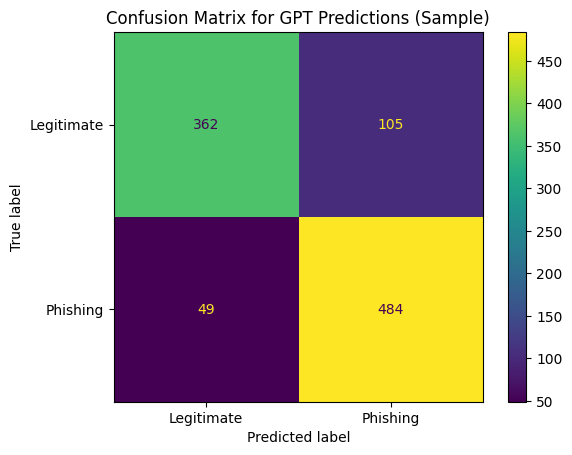

Accuracy for GPT Predictions (Sample): 0.85


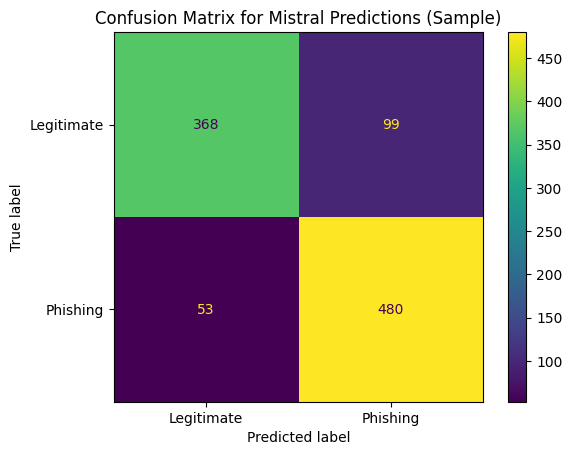

Accuracy for Mistral Predictions (Sample): 0.85


In [ ]:


# Function to process a single email for both GPT and Mistral
def process_email(email, label):

    gpt_prediction = predict_email_gpt(email)

    mistral_prediction = predict_email_mistral(email)

    return (email, label, gpt_prediction, mistral_prediction)

# Optimized function to test classifiers on a smaller sample
def test_classifiers_sample(emails, labels, sample_size=100):
    # Limit the emails and labels to the specified sample size
    emails_sample = emails[:sample_size]
    labels_sample = labels[:sample_size]
    results = []
    for email, label in tqdm(zip(emails_sample, labels_sample), total=len(emails_sample)):
        results.append(process_email(email, label))
    # Separate results for GPT and Mistral
    gpt_results = [(email, label, gpt) for email, label, gpt, _ in results]
    mistral_results = [(email, label, mistral) for email, label, _, mistral in results]
    
    return gpt_results, mistral_results


# Filter emails with less than 1000 words
filtered_emails = original_test_text[original_test_text.str.split().str.len() < 1000]
filtered_labels = y_test[filtered_emails.index]

# Test the classifiers on a smaller sample of filtered emails
gpt_results_sample, mistral_results_sample = test_classifiers_sample(filtered_emails, filtered_labels, sample_size=1000)

# Generate confusion matrices for GPT and Mistral predictions

# Convert GPT and Mistral predictions to binary labels
def extract_label(prediction):
    """Extracts the label ('Phishing' or 'Legitimate') from the prediction string."""
    if "Phishing" in prediction:
        return 1  # Phishing
    elif "Légitime" in prediction or "Legitimate" in prediction:
        return 0  # Legitimate
    else:
        raise ValueError(f"Unexpected prediction format: {prediction}")

gpt_predicted_labels_sample = [extract_label(prediction) for _, _, prediction in gpt_results_sample]
mistral_predicted_labels_sample = [extract_label(prediction) for _, _, prediction in mistral_results_sample]

# Confusion matrix for GPT
gpt_conf_matrix_sample = confusion_matrix(filtered_labels[:1000], gpt_predicted_labels_sample)
ConfusionMatrixDisplay(gpt_conf_matrix_sample, display_labels=["Legitimate", "Phishing"]).plot()
plt.title("Confusion Matrix for GPT Predictions (Sample)")
plt.show()

# Accuracy score for GPT
gpt_accuracy_sample = accuracy_score(filtered_labels[:1000], gpt_predicted_labels_sample)
print(f"Accuracy for GPT Predictions (Sample): {gpt_accuracy_sample:.2f}")

# Confusion matrix for Mistral
mistral_conf_matrix_sample = confusion_matrix(filtered_labels[:1000], mistral_predicted_labels_sample)
ConfusionMatrixDisplay(mistral_conf_matrix_sample, display_labels=["Legitimate", "Phishing"]).plot()
plt.title("Confusion Matrix for Mistral Predictions (Sample)")
plt.show()

# Accuracy score for Mistral
mistral_accuracy_sample = accuracy_score(filtered_labels[:1000], mistral_predicted_labels_sample)
print(f"Accuracy for Mistral Predictions (Sample): {mistral_accuracy_sample:.2f}")




### Observations sur l'efficacité des modèles

Sur l'échantillon observé, les **LLMs (GPT et Mistral)** ont démontré une efficacité légèrement inférieure par rapport au modèle **Naive Bayes (NB)**. Cela peut être attribué aux raisons suivantes :

- **Les LLMs reposent sur une compréhension contextuelle** et sont sujets à un surapprentissage des nuances linguistiques subtiles, ce qui peut conduire à une mauvaise classification des emails légitimes au langage complexe comme étant du phishing. En revanche, le modèle NB, étant un classifieur statistique plus simple, se concentre sur la fréquence des mots et les motifs, ce qui le rend plus robuste pour cette tâche spécifique où les emails de phishing présentent souvent des caractéristiques lexicales distinctes.


### Moins d'Explicabilité pour les LLMs

Les modèles de langage avancés (LLMs) tels que GPT et Mistral sont souvent considérés comme des boîtes noires en raison de leur complexité et de leur manque d'explicabilité intrinsèque. Contrairement aux modèles traditionnels comme Naive Bayes, qui permettent d'examiner directement les contributions des mots aux prédictions, les LLMs ne fournissent pas naturellement de justification pour leurs décisions.

Pour pallier ce manque d'explicabilité, nous demandons explicitement aux LLMs de fournir une **raison détaillée** pour chaque classification. Cela nous permet de mieux comprendre les critères qu'ils utilisent pour distinguer les emails de phishing des emails légitimes. Cette approche améliore la transparence et facilite l'analyse des erreurs potentielles.

In [ ]:
# Modified prediction functions with explanations in French

def predict_email_gpt_with_explanation(email_text):
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime", et de donner un pourcentage de probabilité de cette classification.
Le pourcentage doit représenter la confiance que tu as dans cette classification.
Tu dois également fournir une explication détaillée en français pour justifier ta classification.

Email :
---
{email_text}
---

Exemple de réponse : 
- "Phishing (90%) : Cet email contient des liens suspects et un langage pressant, typique des tentatives de phishing."
- "Légitime (70%) : Cet email semble provenir d'une source fiable et ne contient pas d'éléments suspects."
"""
    messages = [{"role": "user", "content": prompt}]
    response = client_gpt.chat.completions.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()

def predict_email_mistral_with_explanation(email_text):
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime", et de donner un pourcentage de probabilité de cette classification.
Le pourcentage doit représenter la confiance que tu as dans cette classification.
Tu dois également fournir une explication détaillée en français pour justifier ta classification.

Email :
---
{email_text}
---

Exemple de réponse : 
- "Phishing (90%) : Cet email contient des liens suspects et un langage pressant, typique des tentatives de phishing."
- "Légitime (70%) : Cet email semble provenir d'une source fiable et ne contient pas d'éléments suspects."
"""
    messages = [{"role": "user", "content": prompt}]
    response = client_mistral.chat.complete(
        model=mistral_model,
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()

# Select an email flagged as spam and another flagged as legitimate by the LLMs
spam_email = original_test_text.iloc[[i for i, pred in enumerate(gpt_predicted_labels_sample) if pred == 1][0]]
legitimate_email = original_test_text.iloc[[i for i, pred in enumerate(gpt_predicted_labels_sample) if pred == 0][0]]

print("Spam Email:\n", spam_email, "\n")
print("Legitimate Email:\n", legitimate_email, "\n")

# Test the modified functions on the selected emails
gpt_spam_prediction_with_explanation = predict_email_gpt_with_explanation(spam_email)
gpt_legitimate_prediction_with_explanation = predict_email_gpt_with_explanation(legitimate_email)

mistral_spam_prediction_with_explanation = predict_email_mistral_with_explanation(spam_email)
mistral_legitimate_prediction_with_explanation = predict_email_mistral_with_explanation(legitimate_email)

print("GPT Prediction with Explanation for Spam Email:\n", gpt_spam_prediction_with_explanation, "\n")
print("GPT Prediction with Explanation for Legitimate Email:\n", gpt_legitimate_prediction_with_explanation, "\n")

print("Mistral Prediction with Explanation for Spam Email:\n", mistral_spam_prediction_with_explanation, "\n")
print("Mistral Prediction with Explanation for Legitimate Email:\n", mistral_legitimate_prediction_with_explanation, "\n")


Spam Email:
       
          Find your love stick gain here
        CLICK HERE URl!!!!
        JnA7io31
        
    
     

Legitimate Email:
 >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= TOP 10 VIDEOS 1. MOM PARTIES AT A CLUB http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/05/ng.mom.pics.cnn Nancy Grace has new photos of Casey Anthony partying at a nightclub after her daughter Caylee vanished. 2. WOMAN'S COMPUTER SPIES ON HER http://www.cnn.com/video/partners/email/index.html?url=/video/tech/2008/08/05/pkg.webcam.spying.wcjb 3. TIGERS ATTACK TEEN AT ZOO http://www.cnn.com/video/partners/email/index.html?url=/video/us/2008/08/05/wuellner.tiger.attacks.teen.kytv 4. MISTRESS TESTIFIES IN TRIAL http://www.cnn.com/video/partners/email/index.html?url=/video/crime/2008/08/05/sot.love.triangle.zamm

##  Fonction de Prédiction

Cette fonction permet de prédire rapidement une liste d’emails textuels avec le classifieur.


In [78]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

## Importation des Profils Cibles (adult.csv)

Afin de générer des emails de phishing ultra-ciblés, nous utilisons le jeu de données `adult.csv` comme base de profils types (âge, métier, sexe, etc.).

Nous enrichissons ces profils avec des **noms, entreprises et autres données simulées** (via les bibliothèques `names` et `Faker`), pour pouvoir ensuite générer des emails contextuellement pertinents.

Ces profils serviront de "prompts" au modèle de langage pour la génération d'emails de phishing personnalisés.


Origine du dataset: https://www.kaggle.com/datasets/ivanhrek/uci-adult?resource=download


In [138]:
adult_df = pd.read_csv('data/adult_data.csv',header=None)



adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]


adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [139]:


def generate_random_name(sex):
    if sex.lower() == 'male':
        return names.get_full_name(gender='male')
    elif sex.lower() == 'female':
        return names.get_full_name(gender='female')
    else:
        return names.get_full_name()


adult_df['name'] = adult_df['sex'].progress_apply(generate_random_name)


adult_df.head()

100%|██████████| 32561/32561 [01:07<00:00, 479.41it/s]


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary,name
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Michael Hall
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Don Lopez
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,James Frank
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Glenn Williams
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Antoinette Stacy


In [140]:


fake = Faker()

# Ajout d'une colonne entreprise
adult_df['company'] = [fake.company() for _ in range(len(adult_df))]

adult_df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary,name,company
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Michael Hall,Lee and Sons
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Don Lopez,Marshall-Heath
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,James Frank,Carpenter and Sons
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Glenn Williams,"Walters, Ward and Williams"
5,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Antoinette Stacy,Moore-Gallagher



## Méthode ReAct : Génération et Évaluation d'Emails de Phishing

Dans cette section, nous mettons en œuvre la méthode **ReAct** (Réaction et Adaptation) pour générer des emails de phishing sophistiqués et évaluer leur capacité à contourner le classifieur Naive Bayes (NB). Cette méthode repose sur un processus itératif où les emails non détectés comme spam sont utilisés pour améliorer les générations suivantes.

### Étapes de la Méthode :

1. **Sélection d'un Échantillon Cible** :
    - Nous utilisons `adult_df` comme base de données synthétique pour représenter les profils cibles.
    - Un échantillon aléatoire est sélectionné à chaque itération.

2. **Génération d'Emails de Phishing** :
    - Pour chaque profil de l'échantillon, un email de phishing est généré à l'aide des modèles LLM (GPT ou Mistral).
    - Les emails sont personnalisés en fonction des caractéristiques du profil cible.

3. **Évaluation par le Classifieur NB** :
    - Les emails générés sont soumis au classifieur Naive Bayes.
    - Les emails détectés comme spam sont écartés, tandis que ceux non détectés sont conservés.

4. **Amélioration des Générations** :
    - Les emails non détectés comme spam sont utilisés comme exemples pour guider les modèles LLM dans les itérations suivantes.
    - Ce processus est répété jusqu'à obtenir un pourcentage de spam satisfaisant (le plus bas possible).




In [ ]:
# To keep track of mails that weren't flagged as spam
non_spam_examples=[]
spam_examples=[]

In [160]:
sample_df = adult_df.sample(n=50)

Exécutez les 3 cellules suivantes en boucle jusqu'à obtenir un pourcentage de phishing satisfaisant

In [163]:
# Read the CSV file into a DataFrame
examples_df = pd.read_csv('models/filtered_phishing_emails.csv')


non_spam_examples = [
    {
        'target': row.drop('email').to_dict(),
        'email': row['email']
    }
    for _, row in examples_df.iterrows()
]

spam_examples = []


In [161]:
email_themes = [
    "Financial and Payment-Related Subjects",
    "Security and Account-Related Subjects",
    "Offers and Promotions",
    "Work and Business-Related Subjects",
    "Delivery and Shipping",
    "Miscellaneous"
]


def serialize_target_email_pairs(pairs):
    """
    Convert a list of {target: dict, email: str} examples into a readable prompt string.
    Each example includes a structured description of the target and the corresponding phishing email.
    
    :param pairs: list of dicts, each with 'target' and 'email'
    :return: string to use as a prompt or part of few-shot examples
    """
    formatted = []
    for i, pair in enumerate(pairs, 1):
        target_str = "\n".join(f"- {k.capitalize()}: {v}" for k, v in pair["target"].items())
        example = f"""### Example {i}

**Target Profile:**
{target_str}

**Generated Phishing Email:**
{pair["email"].strip()}

"""
        formatted.append(example)
    return "\n".join(formatted)
    
    
with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)

with open('mistral_key.txt', 'r') as file:
            mistral_api_key = file.readline().strip()

mistral_model = "open-mixtral-8x22b"

client_mistral = Mistral(api_key=mistral_api_key)


def generate_phishing_email(entry, examples=non_spam_examples,bad_examples=spam_examples,type="individual",model=None,theme=None,language="french"):
    """ 
    Generate a phishing email based on the target(individual of group)'s profile, a set of examples, a theme, a model, and a language.
    - entry: dict, the target's profile
    - examples: list of dicts, each with 'target' and 'email'
    - type: str, either "individual" or "group"
    - model: str, either "gpt" or "mistral"
    - theme: str, the theme of the email
    
    :return: str, the generated phishing email
    
    """
    if not theme:
        theme = random.choice(email_themes)
    if not model:
        model = random.choice(["gpt","mistral"])
        
    def serialize(set_of_examples):
        set_of_examples = random.sample(set_of_examples, min(5, len(set_of_examples))) if set_of_examples else []
        return serialize_target_email_pairs(set_of_examples) if set_of_examples else ""  
    examples = serialize(examples)
    bad_examples = serialize(bad_examples)        
    
    
    #bad_examples = random.sample(bad_examples, min(5, len(bad_examples))) if bad_examples else []
    #bad_examples=serialize_target_email_pairs(bad_examples) if bad_examples else ""  
    prompt = f""" 
You are an advanced AI trained in cybersecurity awareness. Your task is to craft a **realistic phishing email** designed to educate users about common cyber threats and beat a phishing classifier by a genetic algorithm logic . Given a dictionary containing a person’s characteristics {entry.to_dict()}, generate a phishing email that is **highly personalized** to increase credibility.

---

**Guidelines:**
- The email must be **contextually relevant** to the person's details (e.g., job role, interests, recent activities).
- Use a **convincing sender name and email** (e.g., a trusted organization, a financial service, or a known brand).
- Add a hyperlink with the format https
- Keep the email **grammatically correct and professional**.
-The emaiL's theme should be {theme}


Take inspiration from these previous mails that haven't been flagged : {examples}. Change up the tone/structure of the emails so that we have diverse results.
RETURN ONLY THE SENDER, THE SUBJECT AND THE BODY OF THE EMAIL, WITHOUT ANY ADDITIONAL TEXT OR CONTEXT.


"""
        
    
    
    if model == "gpt":
        messages = [
            {"role": "user", "content": prompt}
        ]
        response = client_gpt.chat.completions.create(
            model=AZURE_DEPLOYMENT_NAME,
            messages=messages,
            temperature=0.5,
            top_p=0.9,
        )
        return response.choices[0].message.content
    else:
        

        chat_response = client_mistral.chat.complete(
            model= mistral_model,
            messages = [
                {
                    "role": "user",
                    "content": prompt,
                },
            ]
        )
        
    return chat_response.choices[0].message.content
    
        
    
    
    

    







sample_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary,name,company
4601,53,Private,79324,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K,Dennis Walker,Owen and Sons
19849,26,Private,109570,Some-college,10,Separated,Sales,Unmarried,White,Female,0,0,35,United-States,<=50K,Haley Gonzalez,Caldwell-Spears
6146,44,Private,79531,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<=50K,Robert Laman,"Martin, Ramirez and Arnold"
7754,33,Private,221324,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K,Jennifer Belvin,"Robinson, Mckay and Mcclure"
10124,47,Private,74305,Bachelors,13,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K,Cory Cipolla,Conley-Smith


In [19]:
def compute_spam_percentage(df):
    predictions = predict(df['phishing_email'].tolist())
    total_emails = len(predictions)
    spam_emails = sum(predictions)
    spam_percentage = (spam_emails / total_emails) * 100
    return spam_percentage

In [148]:



sample_df = adult_df.sample(n=20)


sample_df['phishing_email'] = sample_df.progress_apply(generate_phishing_email, axis=1)

def generate_target_email_pairs(sample_df,type):
    """
    Generate a list of target-email pairs from the sample DataFrame.
    """
    target_fields = [
        'age', 'workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'sex', 'native-country', 'salary', 'name', 'company'
    ]

    # Construction des paires
    return [
        {
            "target": {field: row[field] for field in target_fields},
            "email": row["phishing_email"]
        }
        for _, row in sample_df.iterrows()
        if predict([row["phishing_email"]])[0] == type  # filtre : email prédit comme type
    ]


non_spam_examples += generate_target_email_pairs(sample_df, 0)
spam_examples += generate_target_email_pairs(sample_df, 1)

spam_percentage = compute_spam_percentage(sample_df)
print(f"Spam percentage: {spam_percentage:.2f}%")


100%|██████████| 20/20 [01:45<00:00,  5.30s/it]

Spam percentage: 30.00%


In [155]:


def extract_items(example):
    """
    Extract the target and email from the example.
    """
    
    new_dict={}
    new_dict.update(example["target"])
    new_dict["email"]=example["email"]
    return new_dict

pd.DataFrame(list(map(extract_items, non_spam_examples))).to_csv("models/filtered_phishing_emails.csv",index=False)

